# SPX IV skew와 constant-volatility BSM 비교

고정된 단일 SPX 옵션체인 snapshot으로 두 질문에 답한다.

1. forward 기준 moneyness에서 자체 계산한 implied-volatility skew는 어떤 형태인가?
2. 시장 midpoint와 하나의 ATM IV를 모든 행에 고정한 BSM 가격은 어떻게 다른가?

시장가격은 `mid`를 사용하며, moneyness는 $K/F$와 $\log(K/F)$로 정의한다. 저장된 자체 IV 결과 파일이 없으므로 processed data에서 구현한 함수 `estimate_forward_and_dividend_yield`와 `implied_volatility`를 호출해 새 결과를 만든다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "pyproject.toml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the repository root.")

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from option_pricing_volatility.models.bsm import bsm_price
from option_pricing_volatility.volatility import (
    estimate_forward_and_dividend_yield,
    implied_volatility,
)

pd.options.display.float_format = "{:,.10f}".format
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

In [2]:
MODEL_INPUTS_PATH = (
    PROJECT_ROOT
    / "data/processed/marketdata_spx/SPX_2026-07-15_dte030_pm_sl450_model_inputs.csv"
)
if not MODEL_INPUTS_PATH.is_file():
    raise FileNotFoundError(f"Local model-input snapshot not found: {MODEL_INPUTS_PATH}")

spx_iv_df = pd.read_csv(MODEL_INPUTS_PATH, float_precision="round_trip")
required_columns = {
    "option_symbol",
    "underlying",
    "option_type",
    "strike",
    "spot",
    "T",
    "bid",
    "ask",
    "mid",
    "relative_spread",
    "risk_free_rate",
    "forward",
    "dividend_yield",
    "risk_free_rate_source",
}

# 입력 데이터 유효성 검사를 진행. 위의 required는 무조건 포함해야하며, 
# 각 열에 대해서 유효한 데이터인지 ( SPX, call,put일것, 등등) 확인
# bsm_price, mc_price, crr_price에서의 유효성검사와 동일하다.
missing_columns = sorted(required_columns.difference(spx_iv_df.columns))
if missing_columns:
    raise ValueError(f"Model-input snapshot is missing columns: {missing_columns}")
if set(spx_iv_df["underlying"].dropna()) != {"SPX"}:
    raise ValueError("Expected one SPX snapshot.")
if set(spx_iv_df["option_type"].dropna()) != {"call", "put"}:
    raise ValueError("Expected European call and put rows.")
if spx_iv_df["option_symbol"].duplicated().any():
    raise ValueError("option_symbol must be unique.")
if spx_iv_df.duplicated(["strike", "option_type"]).any():
    raise ValueError("Expected at most one call and put per strike.")
if not np.allclose(
    spx_iv_df["mid"],
    (spx_iv_df["bid"] + spx_iv_df["ask"]) / 2.0,
    rtol=0.0,
    atol=1e-12,
):
    raise ValueError("mid must equal (bid + ask) / 2.")

# 여기 나와있는 열은 모두 unique값이다. 유일하지 않으면 에러 발생.
unique_spot = spx_iv_df["spot"].dropna().unique()
unique_maturity = spx_iv_df["T"].dropna().unique()
unique_rates = spx_iv_df["risk_free_rate"].dropna().unique()
unique_stored_forward = spx_iv_df["forward"].dropna().unique()
unique_stored_q = spx_iv_df["dividend_yield"].dropna().unique()
if not all(
    len(values) == 1
    for values in (
        unique_spot,
        unique_maturity,
        unique_rates,
        unique_stored_forward,
        unique_stored_q,
    )
):
    raise ValueError("The snapshot must have one S, T, r, F, and q.")

# 각 데이터 float으로 형변환.
spot = float(unique_spot[0])
maturity = float(unique_maturity[0])
risk_free_rate = float(unique_rates[0])
forward_estimate = estimate_forward_and_dividend_yield(spx_iv_df, risk_free_rate)
forward = float(forward_estimate.forward)
dividend_yield = float(forward_estimate.dividend_yield)

# 한번더 unique한 데이터셋 forward값과 재계산한 forward값이 오차범위 내 일치하는지 확인한다.
if not np.isclose(forward, float(unique_stored_forward[0]), rtol=0.0, atol=1e-12):
    raise RuntimeError("Recomputed forward does not match the stored model input.")
if not np.isclose(dividend_yield, float(unique_stored_q[0]), rtol=0.0, atol=1e-12):
    raise RuntimeError("Recomputed dividend yield does not match the stored model input.")

input_summary = pd.DataFrame(
    {
        "item": [
            "local snapshot",
            "rows",
            "spot S",
            "maturity T (ACT/365F)",
            "risk-free rate r",
            "forward F",
            "dividend yield q",
            "risk-free rate source",
        ],
        "value": [
            str(MODEL_INPUTS_PATH.relative_to(PROJECT_ROOT)),
            len(spx_iv_df),
            spot,
            maturity,
            risk_free_rate,
            forward,
            dividend_yield,
            spx_iv_df["risk_free_rate_source"].iloc[0],
        ],
    }
)

pd.set_option("display.max_colwidth", None)
display(input_summary)

,item,value
0,local snapshot,data/processed/marketdata_spx/SPX_2026-07-15_dte030_pm_sl450_model_inputs.csv
1,rows,424
2,spot S,"7,572.4102000000"
3,maturity T (ACT/365F),0.0821917808
4,risk-free rate r,0.0366784605
5,forward F,"7,594.9124712050"
6,dividend yield q,0.0005774505
7,risk-free rate source,NEW YORK FED SOFR 2026-07-15 3.62%; r=(365/30)log(sofr*30/360)


## 자체 IV 결과 재생성

424개 각각의 시장 midpoint로부터 iv를 역산한다.

iv 계산시, 성공과 실패를 나누어서, 실패이유를 저장하고

결과 iv 값을 원본에 붙이는 작업을 수행한다.

In [3]:
# 각 행(옵션)마다 새로운 IV 결과 한 행을 만들어 저장한다.
iv_rows = []

"""
pandas df 을 행단위로 반복자를 형성한다. 

implied_volatility 함수는 잘못된 입력값, call/put bound를 넘어가는 경우,
시장가격을 volatility braket [1e-8, 5] 안에서 만들 수 없는 경우에
ValueError를 raise하고, 

지정된 반복수에도 volatiltiy가 수렴하지 않으면 RuntimeError를 발생시킨다.

따라서, try except으로 iv역산 기록 및 실패 사유를 기록한다.
"""
for row in spx_iv_df.itertuples(index=False):
    try:
        result = implied_volatility(
            spot=float(row.spot),
            strike=float(row.strike),
            maturity=float(row.T),
            rate=risk_free_rate,
            market_price=float(row.mid),
            option_type=row.option_type,
            dividend_yield=dividend_yield,
        )
    except (ValueError, RuntimeError) as exc:
        iv_rows.append(
            {
                "implied_volatility": np.nan,
                "repricing_error": np.nan,
                "iv_iterations": np.nan,
                "iv_converged": False,
                "iv_status": "failed",
                "iv_failure_reason": f"{type(exc).__name__}: {exc}",
            }
        )
    else:
        iv_rows.append(
            {
                "implied_volatility": result.volatility,
                "repricing_error": result.repricing_error,
                "iv_iterations": result.iterations,
                "iv_converged": result.converged,
                "iv_status": "success",
                "iv_failure_reason": None,
            }
        )

# concat 메소드를 이용, 원래 df에 iv_rows 정보가 붙은 row들을 붙인다.
spx_iv_df = pd.concat(
    [spx_iv_df, pd.DataFrame(iv_rows, index=spx_iv_df.index)],
    axis=1,
)
if len(spx_iv_df) != len(iv_rows):
    raise RuntimeError("Every input row must retain an IV result status.")

# group by로 status별 요약표 만들기 데이터 프레임을 2개로 쪼갠뒤, 각 그룹에 대해서 
# 3개 숫자를 계산한다.
status_summary = (
    spx_iv_df.groupby("iv_status", sort=False)
    .agg(
        rows=("option_symbol", "size"), # "option_symbol" 열의 행개수를 세고(size), 결과 column이름은 "row"
        calls=("option_type", lambda values: values.eq("call").sum()),
        puts=("option_type", lambda values: values.eq("put").sum()),
    )
    .reset_index()
)
display(status_summary)

,iv_status,rows,calls,puts
0,failed,26,16,10
1,success,398,197,201


## 최종 분석 표본

최종 IV skew를 만들기 전에, 필터링을 진행한다.
긱 필터는 아래 순서로 누적 적용한다.

1. IV 계산 성공 ( implied_volatility 함수 리턴 )
2. finite IV와 finite $\log(K/F)$
3. $0.85 \le K/F \le 1.15$  ( around ATM condition)
4. `relative_spread <= 0.10`
    - mid 값 대비 bid-ask spread값의 비율 제한이다. 이 값이 크면 스프레드가 커져서 시장가격(mid point) 자체가 불안정하다.

In [4]:
# 새로운 moneyness 열을 추가한다.
spx_iv_df["forward_moneyness"] = spx_iv_df["strike"] / forward
spx_iv_df["log_forward_moneyness"] = np.log(spx_iv_df["strike"] / forward)


all_rows_mask = pd.Series(True, index=spx_iv_df.index)

# status가 success이고, 수렴에 도달한 값의 boolean Series
iv_success_mask = spx_iv_df["iv_status"].eq("success") & spx_iv_df["iv_converged"]

# iv값과 log K/F 값이 유한한 행의 boolean Series
finite_mask = (
    iv_success_mask
    & np.isfinite(spx_iv_df["implied_volatility"])
    & np.isfinite(spx_iv_df["log_forward_moneyness"])
)

# moneyness 가 ATM around를 만족하는 boolean Series
moneyness_mask = finite_mask & spx_iv_df["forward_moneyness"].between(0.85, 1.15)
spread_mask = (
    moneyness_mask
    & np.isfinite(spx_iv_df["relative_spread"])
    & spx_iv_df["relative_spread"].le(0.10)
)

# 위에서 계산한 각 필터를 모아놓는다. 
filter_stages = [
    ("전체 model-input 행", all_rows_mask),
    ("IV 계산 성공", iv_success_mask),
    ("finite IV + finite log(K/F)", finite_mask),
    ("0.85 <= K/F <= 1.15", moneyness_mask),
    ("relative_spread <= 0.10", spread_mask),
]

# 필터링 된 단계별로 행으로 담을 객체
filter_rows = []

# 기존 전체 행의 개수
previous_count = len(spx_iv_df)

# 각 필터링을 순회하면서 필터링 된 df 정보를 행으로 새로 담는다. 
for stage, mask in filter_stages:
    selected = spx_iv_df.loc[mask]
    current_count = len(selected)
    filter_rows.append(
        {
            "stage": stage,
            "rows_remaining": current_count,
            "rows_removed_at_stage": previous_count - current_count,
            "calls": selected["option_type"].eq("call").sum(),
            "puts": selected["option_type"].eq("put").sum(),
        }
    )
    previous_count = current_count

# 각 필터링 단계를 나타내는 행들을 하나의 df로 묶는다.
filter_summary = pd.DataFrame(filter_rows)
analysis_df = spx_iv_df.loc[spread_mask].copy()
analysis_df["implied_volatility_pct"] = 100.0 * analysis_df["implied_volatility"]
display(filter_summary)

,stage,rows_remaining,rows_removed_at_stage,calls,puts
0,전체 model-input 행,424,0,213,211
1,IV 계산 성공,398,26,197,201
2,finite IV + finite log(K/F),398,0,197,201
3,0.85 <= K/F <= 1.15,346,52,175,171
4,relative_spread <= 0.10,336,10,165,171


## OTM masking

IV skew에서는 OTM put, OTM call 의 구분이 해석에 중요하다. 따라서,

put,call option의 OTM 필터링을 구현한다.

In [ ]:
# K < F 인 행 마스크
otm_put_mask = analysis_df["option_type"].eq("put") & analysis_df["strike"].lt(forward)

# K >= F 인 행 마스크
otm_call_mask = analysis_df["option_type"].eq("call") & analysis_df["strike"].ge(forward)

# 최종 분석 표본에서 otm put, otm call 만 뽑아서 복사해놓는다.
otm_df = analysis_df.loc[otm_put_mask | otm_call_mask].copy()

# segment 열을 추가하고, 거기에  groupby 분리 기준 을 적어놓는다.
otm_df["segment"] = np.where(
    otm_df["option_type"].eq("put"),
    "OTM put: K < F",
    "OTM call: K >= F",
)
otm_summary = (
    otm_df.groupby("segment", sort=False)
    .agg(
        rows=("option_symbol", "size"),
        min_log_moneyness=("log_forward_moneyness", "min"),
        max_log_moneyness=("log_forward_moneyness", "max"),
        min_iv_pct=("implied_volatility_pct", "min"),
        median_iv_pct=("implied_volatility_pct", "median"),
        max_iv_pct=("implied_volatility_pct", "max"),
    )
    .reset_index()
)
display(otm_summary)

,segment,rows,min_log_moneyness,max_log_moneyness,min_iv_pct,median_iv_pct,max_iv_pct
0,OTM call: K >= F,48,0.0000115246,0.0612942577,9.9589514626,10.9392215240,12.6032259830
1,OTM put: K < F,117,-0.1595300039,-0.0006470200,12.6290672013,17.0867968863,28.6660944080


## 결과 그래프 작성

결과 그래프는 iv skew 그래프 ( log forward moneyness - iv) 이다.

전체 call,put 은 흐린 scatter로 plot하고, OTM만 진하게 표시한다.


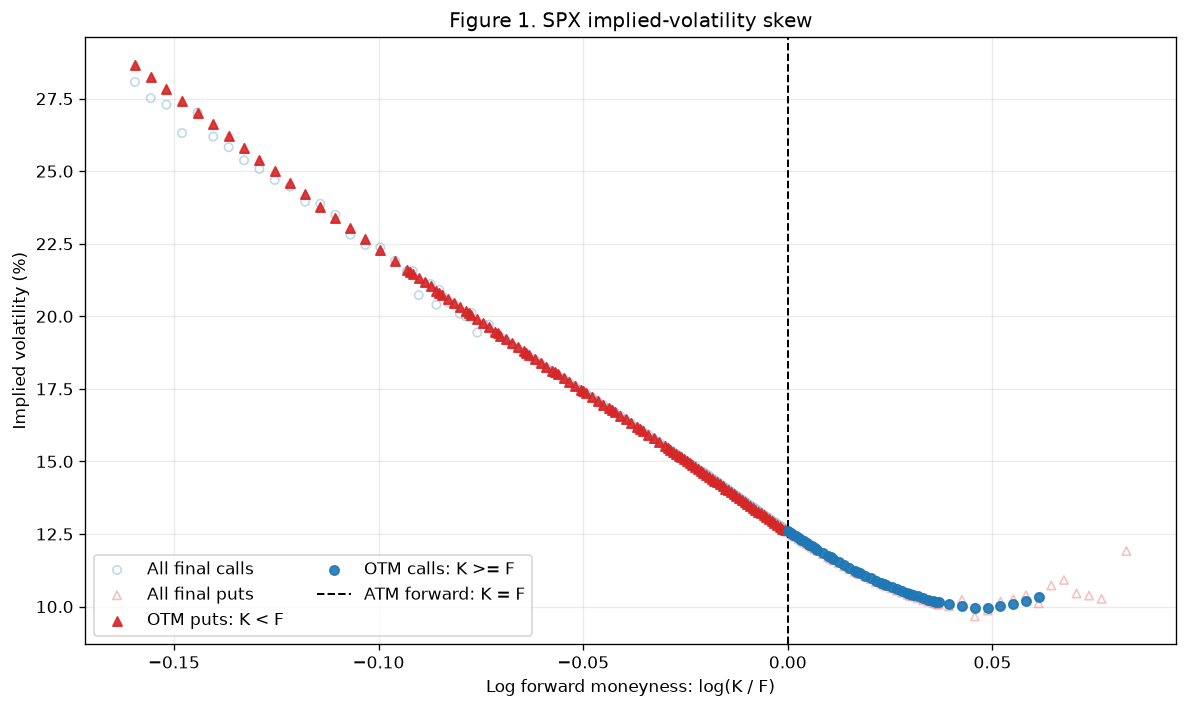

In [ ]:
option_styles = {
    "call": {"color": "#1f77b4", "marker": "o"},
    "put": {"color": "#d62728", "marker": "^"},
}

fig, ax = plt.subplots(figsize=(10, 6))

# 먼저 흐린(투명) 색으로 "전체 call,put"에 대해서 scatter 을 그린다.
for option_type in ("call", "put"):
    subset = analysis_df.loc[analysis_df["option_type"].eq(option_type)]
    style = option_styles[option_type]
    ax.scatter(
        subset["log_forward_moneyness"],
        subset["implied_volatility_pct"],
        marker=style["marker"],
        facecolors="none",
        edgecolors=style["color"],
        alpha=0.28,
        s=25,
        label=f"All final {option_type}s",
    )

# 그리고, OTM인 put, call 부분만 진하게 색칠한다. 
for option_type, mask, label in (
    ("put", otm_put_mask, "OTM puts: K < F"),
    ("call", otm_call_mask, "OTM calls: K >= F"),
):
    subset = analysis_df.loc[mask]
    style = option_styles[option_type]
    ax.scatter(
        subset["log_forward_moneyness"],
        subset["implied_volatility_pct"],
        marker=style["marker"],
        color=style["color"],
        alpha=0.9,
        s=31,
        label=label,
        zorder=3,
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2, label="ATM forward: K = F")
ax.set(
    title="Figure 1. SPX implied-volatility skew",
    xlabel="Log forward moneyness: log(K / F)",
    ylabel="Implied volatility (%)",
)
ax.legend(ncol=2, frameon=True)
fig.tight_layout()
plt.show()

## Constant Volatility BSM

먼저, BSM의 핵심가정은 constant volatility이다. 따라서, iv skew에서 가장 대표적인 하나의 $\sigma_{ATM}$ 을 찾아서 계산해야한다. 

이를 위해서 전체 옵션체인에서 forward와 가장 가까운 strike를 먼저 찾는다.
$$
K_{ATM} = \arg \min_K{|K-F|}
$$
그 strike의 call과 put이 모두 최종 분석 표본에 유효하게 남아 있을 때만 
$$
\sigma_{ATM} = \frac{\sigma_{call} + \sigma_{put}}{2}
$$
으로 사용한다.

어느 한쪽이 없거나 중복되면 대체값 없이 실행을 실패시킨다.

In [ ]:
# 데이터에는 call,put 쌍으로 동일한 strike이 2개씩 존재. 따라서, strike 가격
# 리스트를 만들기 위해 다음을 이용.
unique_strikes = np.sort(spx_iv_df["strike"].dropna().unique().astype(float))
if unique_strikes.size == 0:
    raise RuntimeError("The snapshot contains no finite strike.")

# 유일 strike 리스트에서 F와 가장 가까운 K를 찾는다.
atm_strike = float(unique_strikes[np.argmin(np.abs(unique_strikes - forward))])

# 해당 K값에 대응하는 행들을 복사하고 유효성 검사를 실시한다.
# 유효: call, put의 중복되지 않은 타입 행 2개가 존재하며, iv가 유한함.
atm_rows = analysis_df.loc[analysis_df["strike"].eq(atm_strike)].copy()
if len(atm_rows) != 2 or set(atm_rows["option_type"]) != {"call", "put"}:
    raise RuntimeError(
        f"K_ATM={atm_strike:g} must have one valid call IV and one valid put IV; "
        f"found {atm_rows['option_type'].tolist()}."
    )
if atm_rows["option_type"].duplicated().any():
    raise RuntimeError(f"K_ATM={atm_strike:g} contains a duplicate option type.")
if not np.isfinite(atm_rows["implied_volatility"]).all():
    raise RuntimeError(f"K_ATM={atm_strike:g} contains a non-finite IV.")

# 결과 저장.
atm_iv_by_type = atm_rows.set_index("option_type")["implied_volatility"]
atm_call_iv = float(atm_iv_by_type.loc["call"])
atm_put_iv = float(atm_iv_by_type.loc["put"])
atm_iv_difference = abs(atm_call_iv - atm_put_iv)
sigma_atm = 0.5 * (atm_call_iv + atm_put_iv)

atm_summary = pd.DataFrame(
    {
        "K_ATM": [atm_strike],
        "K_ATM - F": [atm_strike - forward],
        "call_IV": [atm_call_iv],
        "put_IV": [atm_put_iv],
        "abs_IV_difference": [atm_iv_difference],
        "sigma_ATM": [sigma_atm],
    }
)
display(atm_summary)

,K_ATM,K_ATM - F,call_IV,put_IV,abs_IV_difference,sigma_ATM
0,"7,595.0000000000",0.0875287950,0.1260322598,0.1257005078,0.0003317521,0.1258663838


In [ ]:
# iv skew 결과 저장한 df에 방금 계산한 대표 IV 값에 맞는 bsm 가격을 넣는다.
# 리스트 컴프리헨션, 모든 row의 반복자에 대해 bsm 가격을 계산함.
spx_iv_df["constant_vol_bsm_price"] = [
    bsm_price(
        spot=float(row.spot),
        strike=float(row.strike),
        maturity=float(row.T),
        rate=risk_free_rate,
        volatility=sigma_atm,
        option_type=row.option_type,
        dividend_yield=dividend_yield,
    )
    for row in spx_iv_df.itertuples(index=False)
]

# 시장가(mid)와 bsm가격의 차이를 저장한다. 
# ATM에 가까울 수록 차이가 적다.
spx_iv_df["pricing_difference"] = (
    spx_iv_df["mid"] - spx_iv_df["constant_vol_bsm_price"]
)
if not np.isfinite(
    spx_iv_df[["constant_vol_bsm_price", "pricing_difference"]]
).all(axis=None):
    raise RuntimeError("Constant-volatility BSM pricing must be finite for every row.")

analysis_df = spx_iv_df.loc[spread_mask].copy()
error_rows = []
for option_type in ("call", "put"):
    residuals = analysis_df.loc[
        analysis_df["option_type"].eq(option_type),
        "pricing_difference",
    ].to_numpy()
    error_rows.append(
        {
            "option_type": option_type,
            "rows": residuals.size,
            "MAE": np.mean(np.abs(residuals)),
            "RMSE": np.sqrt(np.mean(np.square(residuals))),
        }
    )
error_summary = pd.DataFrame(error_rows)
display(error_summary)

,option_type,rows,MAE,RMSE
0,call,165,12.1227716307,13.4186383594
1,put,171,11.8762354254,13.2905931036


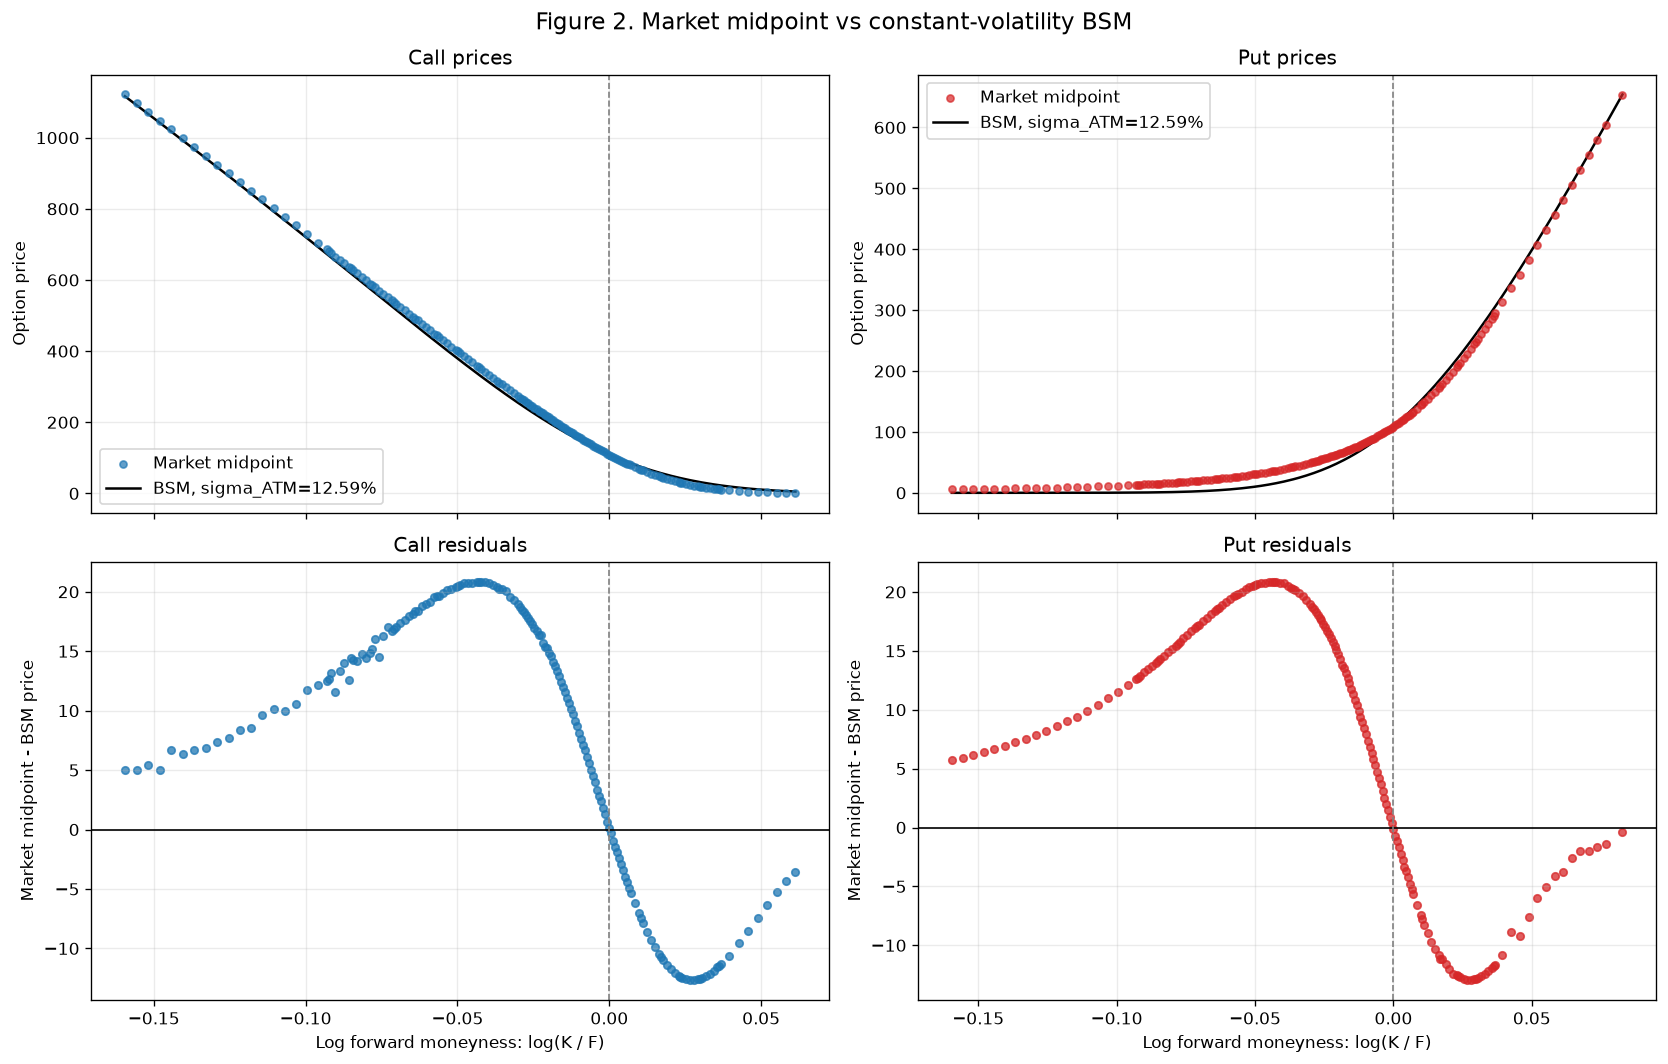

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
for column, option_type in enumerate(("call", "put")):
    subset = (
        analysis_df.loc[analysis_df["option_type"].eq(option_type)]
        .sort_values("log_forward_moneyness")
    )
    color = option_styles[option_type]["color"]
    x = subset["log_forward_moneyness"]

    price_ax = axes[0, column]
    price_ax.scatter(
        x,
        subset["mid"],
        color=color,
        alpha=0.7,
        s=18,
        label="Market midpoint",
        zorder=3,
    )
    price_ax.plot(
        x,
        subset["constant_vol_bsm_price"],
        color="black",
        linewidth=1.5,
        label=f"BSM, sigma_ATM={sigma_atm:.2%}",
    )
    price_ax.axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    price_ax.set_title(f"{option_type.capitalize()} prices")
    price_ax.set_ylabel("Option price")
    price_ax.legend()

    residual_ax = axes[1, column]
    residual_ax.scatter(
        x,
        subset["pricing_difference"],
        color=color,
        alpha=0.75,
        s=20,
    )
    residual_ax.axhline(0.0, color="black", linewidth=1.0)
    residual_ax.axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    residual_ax.set(
        xlabel="Log forward moneyness: log(K / F)",
        ylabel="Market midpoint - BSM price",
        title=f"{option_type.capitalize()} residuals",
    )

fig.suptitle("Figure 2. Market midpoint vs constant-volatility BSM", fontsize=14)
fig.tight_layout()
plt.show()